# Econ 8208 Assignment 5

- Author: Yuxuan Zhao
- Date: 2026-04-01

In [43]:
using LinearAlgebra
# Using defined functions in ECON8208Tools.jl
include("../ECON8208Tools.jl")
import .ECON8208Tools as tools



# HW 5

Compute the following growth model:


\begin{aligned}
\max_{\{c_t,x_t,\ell_t\}} \quad & E \sum_{t=0}^{\infty} \beta^t 
\left\{ \frac{(c_t \ell_t^{\psi})^{1-\sigma}}{1-\sigma} \right\} N_t \\
\text{s.t.} \quad 
& c_t + x_t = k_t^{\theta}\bigl((1+\gamma_z)^t z_t h_t\bigr)^{1-\theta}, \\
& N_{t+1}  k_{t+1} = \bigl[(1-\delta)k_t + x_t\bigr] N_t, \\
& \log z_t = \rho \log z_{t-1} + \epsilon_t, \qquad \epsilon_t \sim N(0,\sigma_\epsilon^2), \\
& h_t + \ell_t = 1, \\
& N_t = (1+\gamma_n)^t, \\
& k_0 \text{ given.}
\end{aligned}


This model implies a balanced growth path, the grid of the state variable $k_t$ will grow over time, and we cannot solve the model using value function iteration, thus we need to detrend the variables to solve the model.

Define the detrended variables as follows:
\begin{aligned}
\tilde{c}_t = \frac{c_t}{(1+\gamma_z)^t}, \quad
\tilde{x}_t = \frac{x_t}{(1+\gamma_z)^t}, \quad
\tilde{k}_t = \frac{k_t}{(1+\gamma_z)^t}, \quad
\tilde{h}_t = h_t, \quad
\tilde{\ell}_t = \ell_t.
\end{aligned}

Then the period utility becomes
$$
N_t \frac{(c_t \ell_t^\psi)^{1-\sigma}}{1-\sigma}
=
(1+\gamma_n)^t (1+\gamma_z)^{t(1-\sigma)}
\frac{(\tilde{c}_t \tilde{\ell}_t^\psi)^{1-\sigma}}{1-\sigma}.
$$

Therefore, after detrending, the Bellman equation uses the effective discount factor
$$
\tilde{\beta}
=
\beta (1+\gamma_n)(1+\gamma_z)^{1-\sigma}.
$$

The detrended problem can be written as:
\begin{aligned}
\max_{\{\tilde{c}_t,\tilde{x}_t,\tilde{\ell}_t\}} \quad & E \sum_{t=0}^{\infty} \tilde{\beta}^t 
\left\{ \frac{(\tilde{c}_t \tilde{\ell}_t^{\psi})^{1-\sigma}}{1-\sigma} \right\} \\
\text{s.t.} \quad
& \tilde{c}_t + \tilde{x}_t = \tilde{k}_t^{\theta}\bigl( z_t \tilde{h}_t\bigr)^{1-\theta}, \\
& \tilde{k}_{t+1} = \frac{(1-\delta)\tilde{k}_t + \tilde{x}_t}{(1+\gamma_n)(1+\gamma_z)}, \\
& \log z_t = \rho \log z_{t-1} + \epsilon_t, \qquad \epsilon_t \sim N(0,\sigma_\epsilon^2), \\
& \tilde{h}_t + \tilde{\ell}_t = 1, \\
& \tilde{k}_0 = k_0.
\end{aligned}


In [44]:
# -------------------------------------------------------
# Initialize parameters
# -------------------------------------------------------

beta = 0.96          # discount factor
psi = 1.50          # utility weight on leisure
sigma = 2.00          # coefficient of relative risk aversion
gamma_n = 0.01        # population growth rate
gamma_z = 0.02        # labor-augmenting technology growth rate
theta = 0.36          # capital share in production
delta = 0.08          # depreciation rate
rho = 0.90          # persistence of productivity shock
sigma_e = 0.02        # standard deviation of productivity shock

# -------------------------------------------------------
# Derived growth objects after detrending
# -------------------------------------------------------

G = (1.0 + gamma_n) * (1.0 + gamma_z)
beta_tilde = beta * (1.0 + gamma_n) * (1.0 + gamma_z)^(1.0 - sigma)

# -------------------------------------------------------
# Additional settings for computation
# -------------------------------------------------------

# problem (a)
n_k = 1500         # number of grid points for capital
m_k = 4.0          # upper bound multiplier for capital grid
n_z = 5           # number of grid points for productivity
tol = 1e-6        # convergence tolerance
max_iter = 1000   # maximum number of iterations

# problem (b)
hstep_lq = 1e-6    # step size for numerical derivatives in LQ approximation

# -------------------------------------------------------
# Initial productivity state
# -------------------------------------------------------

z_ss = 1.0        # steady-state productivity
logz_ss = 0.0     # steady-state log productivity

# -------------------------------------------------------
# Initial capital condition
# Will be updated after computing steady-state capital
# -------------------------------------------------------

k0 = nothing


## a) Solve the model using value function iteration.

We can rewrite the detrended household problem as the following Bellman equation:
$$
\begin{aligned}
V(\tilde{k},z)
=
\max_{\tilde{k}',\,\tilde{h}}
\quad
\Biggl\{
&
\frac{
\left[
\tilde{c}
(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma}
+ \tilde{\beta} E\bigl[V(\tilde{k}',z')\bigr]
\Biggr\}, \\
\text{s.t.} \quad
\log z' &= \rho \log z + \epsilon',
\quad
\epsilon' \sim N(0,\sigma_\epsilon^2), \\
\tilde{c} &= \tilde{k}^\theta (z \tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}, \\
\tilde{k}' &\ge 0, \\
0 &\le \tilde{h} \le 1, \\
\tilde{c} &> 0,
\end{aligned}
$$


The dimensionality of this problem (a) is:
$$
n_k \times n_z \times n_h \times n_{k'}
$$

Which is too high for value function iteration to solve. Notice that the choice of $\tilde{h}$ is a static problem, we can solve for $\tilde{h}$ first, thus reducing the dimensionality of the problem.

Given $\tilde{k}, z, \tilde{k}'$, household chooses $\tilde{h}$ to maximize:
$$
\begin{aligned}
&\max_{\tilde{h}} \frac{
\left[
\tilde{c}
(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma} \quad \text{s.t.}\\
\tilde{c} &= \tilde{k}^\theta (z \tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}, \\
\tilde{c} &> 0, \\
0 &\le \tilde{h} \le 1.
\end{aligned}
$$

We can write the first order condition for $\tilde{h}$ as:
$$
\frac{(1-\theta)\tilde{k}^{\theta} z^{1-\theta}\tilde{h}^{-\theta}}
{\tilde{k}^{\theta}(z\tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}}
=
\frac{\psi}{1-\tilde{h}}.
$$

Solve the above equation for $\tilde{h}$, we can get the optimal labor supply $\tilde{h}^*(\tilde{k}, z, \tilde{k}')$. Then we can substitute $\tilde{h}^*$ back into the Bellman equation:
$$
\begin{aligned}
V(\tilde{k},z)
=
\max_{\tilde{k}'}
\quad
\Biggl\{
&
\frac{\left[
\tilde{c}^*
(1-\tilde{h}^*(\tilde{k}, z, \tilde{k}'))^\psi
\right]^{1-\sigma}}{1-\sigma}
+ \tilde{\beta} E\bigl[V(\tilde{k}',z')\bigr]
\Biggr\}, \\
\text{s.t.} \quad
\log z' &= \rho \log z + \epsilon',
\quad
\epsilon' \sim N(0,\sigma_\epsilon^2), \\
\tilde{c}^* &= \tilde{k}^\theta (z \tilde{h}^*(\tilde{k}, z, \tilde{k}'))^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}, \\
\tilde{k}' &\ge 0, \\
\tilde{c}^* &> 0.
\end{aligned}
$$


### Solving steady state

The steady-state values $(\tilde{k}^{ss}, \tilde{h}^{ss}, \tilde{c}^{ss})$ are determined by the following system:
$$
\begin{aligned}
\tilde{c}^{ss}
&=
(\tilde{k}^{ss})^\theta (\tilde{h}^{ss})^{1-\theta}
-
\bigl((1+\gamma_n)(1+\gamma_z)-(1-\delta)\bigr)\tilde{k}^{ss}, \\
\frac{1}{\tilde{\beta}}
&=
\frac{1-\delta+\theta (\tilde{k}^{ss})^{\theta-1} (\tilde{h}^{ss})^{1-\theta}}{(1+\gamma_n)(1+\gamma_z)}, \\
\frac{\psi}{1-\tilde{h}^{ss}}
&=
\frac{(1-\theta)(\tilde{k}^{ss})^\theta (\tilde{h}^{ss})^{-\theta}}
{\tilde{c}^{ss}}.
\end{aligned}
$$

The first equation is the steady-state resource constraint, the second equation is the steady-state Euler equation, and the third equation is the steady-state labor first-order condition.

We apply Newton's method to solve for the steady-state values
$$
\tilde{k}^{ss}, \qquad \tilde{h}^{ss}, \qquad \tilde{c}^{ss}.
$$


In [45]:
k_ss, h_ss, c_ss = tools.solve_steady_state_newton(
    beta_tilde, psi, theta, delta, gamma_n, gamma_z;
    x0=[1.5, 0.3, 0.4],
    tol=1e-10,
    max_iter=100,
    hstep=1e-6
)
println("steady-state labor h_ss = ", h_ss)
println("steady-state capital k_ss = ", k_ss)
println("steady-state consumption c_ss = ", c_ss)


Steady state converged in 6 iterations.
steady-state labor h_ss = 0.36024020596940015
steady-state capital k_ss = 1.2335493958679273
steady-state consumption c_ss = 0.4251565053902804


### Grid construction for value function iteration

1. **Construct asset grids**

After discretizing the productivity process, we obtain the grid
$$
z_1, z_2, \dots, z_{n_z},
$$
and the transition matrix $P_z$.

Let
$$
z_{\max} = \max \{ z_1, z_2, \dots, z_{n_z} \}.
$$

2. **Construct capital grids**

To construct the capital grid, we first compute the steady-state capital level $\tilde{k}^{ss}$.  
In the stationary detrended model, the steady state satisfies
$$
z = 1, \qquad \tilde{k}' = \tilde{k} = \tilde{k}^{ss}, \qquad \tilde{h} = \tilde{h}^{ss}, \qquad \tilde{c} = \tilde{c}^{ss}.
$$

We then construct the capital grid as an evenly spaced grid centered around $\tilde{k}^{ss}$.  
Specifically, we choose the interval
$$
[\underline{k}, \bar{k}]
=
\left[10^{-5}, (1+m_k)\,\tilde{k}^{ss}\right]
$$
and construct $n_k$ evenly spaced grid points over this interval.

Thus, the capital grid is
$$
\tilde{k}_1 = \underline{k}, \qquad
\tilde{k}_2, \qquad \dots, \qquad
\tilde{k}_{n_k} = \bar{k}.
$$

This choice concentrates the grid around the economically relevant region near the steady state, which improves the accuracy of value function iteration.


In [46]:
# -------------------------------------------------------
# Grid construction
# -------------------------------------------------------

# Construct productivity grid and transition matrix
z_grid, Pz = tools.tauchen(rho, sigma_e, n_z)

# -------------------------------------------------------
# Construct capital grid around the steady state
# -------------------------------------------------------

k_lower = 1e-5
k_upper = (1 + m_k) * k_ss

# If the user provides an initial capital outside this interval,
# enlarge the grid so that it contains k0
if k0 !== nothing
    k_lower = min(k_lower, k0)
    k_upper = max(k_upper, k0)
end

k_grid = collect(range(k_lower, k_upper, length=n_k))

println("capital grid lower bound = ", first(k_grid))
println("capital grid upper bound = ", last(k_grid))


capital grid lower bound = 1.0e-5
capital grid upper bound = 6.167746979339636


### Compute optimal labor supply $\tilde{h}^*$ for each $(\tilde{k}, z, \tilde{k}')$ on the grid

We know that the optimal labor supply $\tilde{h}^*$ satisfies the first-order condition
$$
\frac{(1-\theta)\tilde{k}^{\theta} z^{1-\theta}\tilde{h}^{-\theta}}
{\tilde{k}^{\theta}(z\tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}}
=
\frac{\psi}{1-\tilde{h}}.
$$

For each triple $(\tilde{k}, z, \tilde{k}')$ on the grid, we can solve the above equation for $\tilde{h}$ using numerical root-finding methods, and store the optimal labor supply $\tilde{h}^*(\tilde{k}, z, \tilde{k}')$ in a 3D array.

Write $G(\tilde{h}; \tilde{k}, z, \tilde{k}')$ as:
$$
G(\tilde{h}; \tilde{k}, z, \tilde{k}')
=
\frac{(1-\theta)\tilde{k}^{\theta} z^{1-\theta}\tilde{h}^{-\theta}}
{\tilde{k}^{\theta}(z\tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}}
-
\frac{\psi}{1-\tilde{h}}.
$$

Use numerical root-finding methods to solve $G(\tilde{h}; \tilde{k}, z, \tilde{k}') = 0$ for $\tilde{h}$, and store the solution as $\tilde{h}^*(\tilde{k}, z, \tilde{k}')$.

If the solution is infeasible:
$$
\tilde{c} = \tilde{k}^\theta (z \tilde{h}^*)^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k} \le 0, \\
\tilde{h}^* < 0, \quad \text{or} \quad \tilde{h}^* > 1,
$$
Return an NaN value for $\tilde{h}^*(\tilde{k}, z, \tilde{k}')$ to indicate that this choice is infeasible.


Let
$$
\tilde{k}_i \in \{\tilde{k}_1,\dots,\tilde{k}_{n_k}\},
\qquad
z_j \in \{z_1,\dots,z_{n_z}\},
$$

Let $\Pi_z(z,z')$ denote the transition probability from current productivity state $z$ to next-period productivity state $z'$.

Compute the optimal labor supply $\tilde{h}^*(\tilde{k}_i, z_j, \tilde{k}_p)$ for each triple $(\tilde{k}_i, z_j, \tilde{k}_p)$ on the grid, and store the results in a 3D array $\tilde{h}^*_{i,j,p}$.


In [47]:
# -------------------------------------------------------
# Compute h* using Newton's method
# Input:
#   k_grid, z_grid : grids for capital and productivity
#   Other parameters as before
# Output:
#   h_star_grid[ik, iz, ikp] = h*(k, z, k')
# -------------------------------------------------------
h_star = tools.compute_h_star(
    k_grid, z_grid, psi, theta, delta, gamma_n, gamma_z;
    h0=0.5, tol=1e-8, max_iter=100, hstep=1e-6, alpha=0.3
);



MethodError: MethodError: no method matching compute_h_star(::Vector{Float64}, ::Vector{Float64}, ::Float64, ::Float64, ::Float64, ::Float64; h0::Float64, tol::Float64, max_iter::Int64, hstep::Float64, alpha::Float64)
The function `compute_h_star` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  compute_h_star(::Any, ::Any, ::Any, ::Any, ::Any, ::Any, !Matched::Any; h0, tol, max_iter, hstep, alpha)
   @ Main.ECON8208Tools c:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8208\ECON8208Tools.jl:779


Substituting $\tilde{h}^*$ into the Bellman equation, the problem becomes
$$
\begin{aligned}
V(\tilde{k},z)
=
\max_{\tilde{k}'}
\quad
\Biggl\{
&
\frac{
\left[
\tilde{c}^*(\tilde{k},z,\tilde{k}')
\left(1-\tilde{h}^*(\tilde{k},z,\tilde{k}')\right)^\psi
\right]^{1-\sigma}
}{1-\sigma}
+
\tilde{\beta}
\sum_{z' \in Z}
\Pi_z(z,z')\,V(\tilde{k}',z')
\Biggr\}, \\
\text{s.t.} \quad
& \tilde{c}^*(\tilde{k},z,\tilde{k}')
=
\tilde{k}^\theta
\left(z\,\tilde{h}^*(\tilde{k},z,\tilde{k}')\right)^{1-\theta}
-
(1+\gamma_n)(1+\gamma_z)\tilde{k}'
+
(1-\delta)\tilde{k}, \\
& z' \mid z \sim P_z(z,z'), \\
& \tilde{k}' \ge 0, \\
& \tilde{c}^*(\tilde{k},z,\tilde{k}') > 0,
\end{aligned}
$$

Howard policy function iteration speeds up the solution by separating policy improvement from policy evaluation.

1. **Initialize**

- Set an initial value function $V_0(\tilde{k},z)$.
- Set an initial policy function for next-period capital
  $$
  g_k^0(\tilde{k},z).
  $$

2. **Policy Improvement**

- Given the current value function $V_n(\tilde{k},z)$, solve
  $$
  g_k^{n+1}(\tilde{k},z)
  =
  \arg\max_{\tilde{k}'}
  \Biggl\{
  \frac{
  \left[
  \tilde{c}^*(\tilde{k},z,\tilde{k}')
  \left(1-\tilde{h}^*(\tilde{k},z,\tilde{k}')\right)^\psi
  \right]^{1-\sigma}
  }{1-\sigma}
  +
  \tilde{\beta}
  \sum_{z' \in Z}
  \Pi_z(z,z')\,V_n(\tilde{k}',z')
  \Biggr\},
  $$
  subject to
  $$
  \tilde{k}' \ge 0,
  \qquad
  \tilde{c}^*(\tilde{k},z,\tilde{k}') > 0.
  $$

- Once $g_k^{n+1}(\tilde{k},z)$ is determined, recover labor from
  $$
  g_h^{n+1}(\tilde{k},z)
  =
  \tilde{h}^*(\tilde{k},z,g_k^{n+1}(\tilde{k},z)).
  $$

3. **Policy Evaluation**

- Hold the policy functions fixed at
  $$
  g_k^{n+1}(\tilde{k},z), \qquad g_h^{n+1}(\tilde{k},z).
  $$
- For each state $(\tilde{k},z)$, compute the implied consumption
  $$
  \tilde{c}
  =
  \tilde{k}^\theta \bigl(z\,g_h^{n+1}(\tilde{k},z)\bigr)^{1-\theta}
  -
  (1+\gamma_n)(1+\gamma_z)g_k^{n+1}(\tilde{k},z)
  +
  (1-\delta)\tilde{k}.
  $$
- Update the value function repeatedly under the fixed policy:
  $$
  V_{m+1}(\tilde{k},z)
  =
  \frac{
  \left[
  \tilde{c}\,(1-g_h^{n+1}(\tilde{k},z))^\psi
  \right]^{1-\sigma}
  }{1-\sigma}
  +
  \tilde{\beta}
  \sum_{z' \in Z}
  \Pi_z(z,z')\,V_m(g_k^{n+1}(\tilde{k},z),z').
  $$
- Perform this policy evaluation step for several iterations while keeping the policy fixed.

4. **Convergence Check**

- After the policy improvement step, record the number of grid points at which the policy function changes:
  $$
  n_{\text{change}}
  =
  \#\left\{
  (\tilde{k},z)
  :
  g_k^{n+1}(\tilde{k},z) \neq g_k^n(\tilde{k},z)
  \right\}.
  $$
- If
  $$
  n_{\text{change}} = 0,
  $$
  then the policy function is stable on the grid, and the algorithm has converged.
- Otherwise, set
  $$
  V_n \leftarrow V_{n+1},
  \qquad
  g_k^n \leftarrow g_k^{n+1},
  $$
  and repeat Steps 2--4.


Howard policy function iteration is faster than standard value function iteration because the maximization problem is now one-dimensional in $\tilde{k}'$, while labor is recovered from the static first-order condition.


In [48]:
# -------------------------------------------------------
# Test Howard policy iteration using precomputed h_star
# -------------------------------------------------------
V_howard, pol_kp_howard, pol_h_howard = tools.solve_pfi_howard(
    beta_tilde, psi, sigma, gamma_n, gamma_z, theta, delta,
    k_grid, z_grid, Pz, h_star;
    tol=tol, max_iter=max_iter, howard_iter=20
);


Howard iteration = 1, policy changes = 0
Howard iteration = 2, policy changes = 7495
Howard iteration = 3, policy changes = 7500
Howard iteration = 4, policy changes = 7389
Howard iteration = 5, policy changes = 7308
Howard iteration = 6, policy changes = 6911
Howard iteration = 7, policy changes = 6267
Howard iteration = 8, policy changes = 5346
Howard iteration = 9, policy changes = 3972
Howard iteration = 10, policy changes = 2621
Howard iteration = 11, policy changes = 1611
Howard iteration = 12, policy changes = 873
Howard iteration = 13, policy changes = 420
Howard iteration = 14, policy changes = 184
Howard iteration = 15, policy changes = 49
Howard iteration = 16, policy changes = 14
Howard iteration = 17, policy changes = 1
Howard iteration = 18, policy changes = 0
Howard policy iteration converged in 18 iterations.


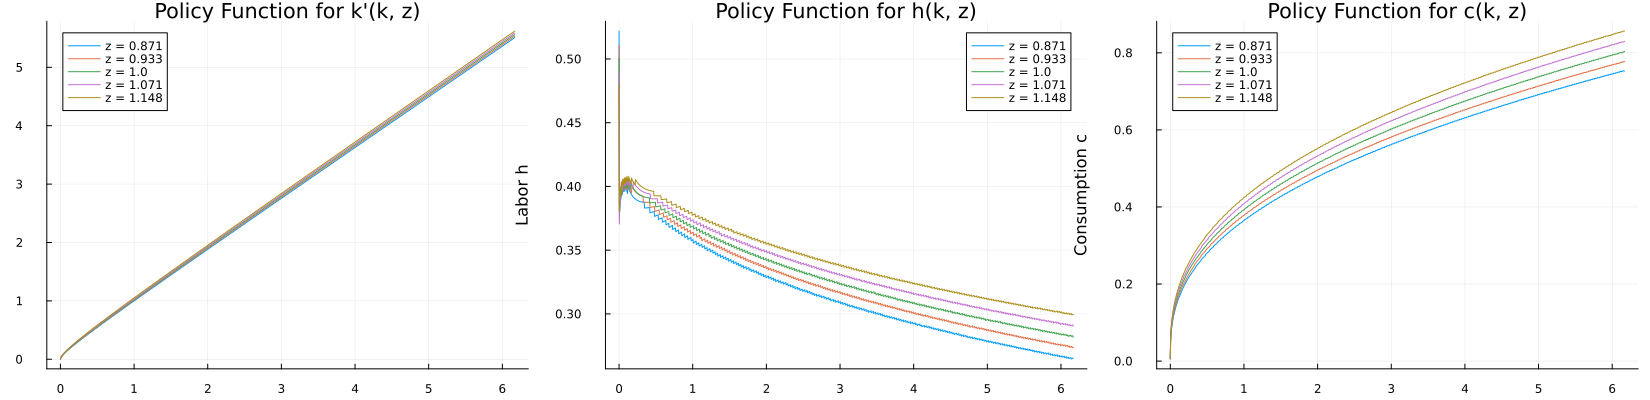

In [49]:
using Plots

# -------------------------------------------------------
# Plot policy functions
# Horizontal axis: current capital k
# Vertical axis: policy values
# Different productivity states z are shown as different lines
# -------------------------------------------------------

# Plot policy function for next-period capital k'(k, z)
p1 = plot(
    xlabel = "Current capital k",
    ylabel = "Next-period capital k'",
    title = "Policy Function for k'(k, z)",
    linewidth = 2
)

for iz in 1:length(z_grid)
    plot!(
        p1,
        k_grid,
        pol_kp_howard[:, iz],
        label = "z = $(round(z_grid[iz], digits=3))"
    )
end

# Plot policy function for labor h(k, z)
p2 = plot(
    xlabel = "Current capital k",
    ylabel = "Labor h",
    title = "Policy Function for h(k, z)",
    linewidth = 2
)

for iz in 1:length(z_grid)
    plot!(
        p2,
        k_grid,
        pol_h_howard[:, iz],
        label = "z = $(round(z_grid[iz], digits=3))"
    )
end

# -------------------------------------------------------
# Compute policy function for consumption c(k, z)
# implied by the policy functions for k' and h
# -------------------------------------------------------
pol_c_howard = zeros(size(pol_kp_howard))

for ik in 1:length(k_grid)
    k = k_grid[ik]

    for iz in 1:length(z_grid)
        z = z_grid[iz]
        kp = pol_kp_howard[ik, iz]
        h = pol_h_howard[ik, iz]

        pol_c_howard[ik, iz] =
            k^theta * (z * h)^(1.0 - theta) -
            G * kp +
            (1.0 - delta) * k
    end
end

# Plot policy function for consumption c(k, z)
p3 = plot(
    xlabel = "Current capital k",
    ylabel = "Consumption c",
    title = "Policy Function for c(k, z)",
    linewidth = 2
)

for iz in 1:length(z_grid)
    plot!(
        p3,
        k_grid,
        pol_c_howard[:, iz],
        label = "z = $(round(z_grid[iz], digits=3))"
    )
end

plot(p1, p2, p3, layout = (1, 3), size = (1650, 400))


Given an acceptable grid density, the Howard policy function iteration still takes a long time to converge, and the results are not very accurate, especially for the policy functions $\tilde h(\tilde k, z)$

### Recover the policy functions of original problem

We've solved the detrended problem and obtained the optimal policy functions for next-period capital and labor supply:
$$\tilde{k}' = g_k(\tilde{k}, z), \qquad \tilde{h} = g_h(\tilde{k}, z), \qquad \tilde{c} = g_c(\tilde{k}, z).$$

To recover the policy functions of the original problem, we can use the definitions of the detrended variables:
$$
\tilde{c}_t = \frac{c_t}{(1+\gamma_z)^t}, \quad
\tilde{x}_t = \frac{x_t}{(1+\gamma_z)^t}, \quad
\tilde{k}_t = \frac{k_t}{(1+\gamma_z)^t}, \quad
\tilde{h}_t = h_t, \quad
\tilde{\ell}_t = \ell_t.
$$

Then we have:
$$
\begin{aligned}
k_{t+1} &= \tilde{k}_{t+1} (1+\gamma_z)^{t+1} = g_k\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) (1+\gamma_z)^{t+1}, \\
c_t &= \tilde{c}_t (1+\gamma_z)^t = g_c\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) (1+\gamma_z)^t, \\
x_t &= \tilde{x}_t (1+\gamma_z)^t = \left[(1+\gamma_n)(1+\gamma_z)g_k\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) - (1-\delta)\frac{k_t}{(1+\gamma_z)^t}\right] (1+\gamma_z)^t, \\
h_t &= \tilde{h}_t = g_h\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right), \\
\ell_t &= 1 - h_t = 1 - g_h\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right).
\end{aligned}
$$


## (b) Solve the model using LQ approximation method

We have the detrended problem:
$$
\begin{aligned}
V(\tilde{k},z)
=
\max_{\tilde{k}',\,\tilde{h}}
\quad
\Biggl\{
&
\frac{
\left[
\tilde{c}(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma}
+ \tilde{\beta} E\bigl[V(\tilde{k}',z')\bigr]
\Biggr\}, \\
\text{s.t.} \quad
\log z' &= \rho \log z + \epsilon',
\qquad
\epsilon' \sim N(0,\sigma_\epsilon^2), \\
\tilde{c} &= \tilde{k}^\theta (z \tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}, \\
\tilde{k}' &\ge 0, \\
0 &\le \tilde{h} \le 1, \\
\tilde{c} &> 0.
\end{aligned}
$$

And we have solved for the steady-state values
$$
(\tilde{k}^{ss}, \tilde{h}^{ss}, \tilde{c}^{ss}).
$$

To apply the LQ approximation, define:
$$
x =
\begin{bmatrix}
\tilde{k} \\
a
\end{bmatrix},
\qquad
u =
\begin{bmatrix}
\tilde{k}' \\
\tilde{h}
\end{bmatrix}, \qquad
a = \log z.
$$

Then we have $r(x,u)$:
$$
r(x,u)
=
\frac{
\left[
\tilde{c}(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma}
=
\frac{
\left[
\left(\tilde{k}^\theta
\left(e^a \tilde{h}\right)^{1-\theta}
-
(1+\gamma_n)(1+\gamma_z)\tilde{k}'
+
(1-\delta)\tilde{k}\right)(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma}.
$$

Then we have $g(x,u)$:
$$
g(x,u)
=
\begin{bmatrix}
\tilde{k}' \\
\rho a
\end{bmatrix}.
$$
such that
$$
x' =
g(x,u)
+
\begin{bmatrix}
0 \\
\epsilon'
\end{bmatrix}.
$$

We approximate the nonlinear problem locally around the deterministic steady state.  
Let
$$
\bar{x}
=
\begin{bmatrix}
\tilde{k}^{ss} \\
0
\end{bmatrix},
\qquad
\bar{u}
=
\begin{bmatrix}
\tilde{k}^{ss} \\
\tilde{h}^{ss}
\end{bmatrix}.
$$

Define deviations from the steady state by
$$
\hat{x}_t = x_t - \bar{x},
\qquad
\hat{u}_t = u_t - \bar{u}.
$$

The problem is to solve the infinite-horizon LQ problem:
$$
\hat V(\hat x) = \max_{\{\hat u_t\}} \sum_{t=0}^{\infty} \tilde{\beta}^t
\left(
\hat x_t' Q \hat x_t + 2 \hat x_t' W \hat u_t + \hat u_t' R \hat u_t
\right) \quad \text{s.t.} \\
\hat x_{t+1} = A \hat x_t + B \hat u_t + \begin{bmatrix} 0 \\ \epsilon_{t+1} \end{bmatrix}.
$$
where the matrices $(Q,W,R,A,B)$ are computed from Taylor expansion of $r(x,u)$ and $g(x,u)$ around the steady state $(\bar{x}, \bar{u})$.

### Solving the LQ problem using the Riccati equation

Because we use the linear-quadratic approximation, the problem satisfies certainty equivalence. Hence, the optimal policy is linear in the state variables, and we can apply the standard Riccati equation to solve for the value function and the policy rule.

First, we guess that the value function is quadratic in the state variables:
$$
\hat V(\hat x) = \hat x' P \hat x.
$$

Substituting this guess into the Bellman equation and taking the first-order condition with respect to $\hat u$, we obtain the policy rule
$$
\hat u = -F \hat x,
$$
where
$$
F = \left(R + \tilde{\beta} B' P B\right)^{-1}\left(W' + \tilde{\beta} B' P A\right).
$$

Substituting the policy rule back into the Bellman equation gives the Riccati equation:
$$
P
=
Q - F'W' - WF + F'RF + \tilde{\beta} (A - BF)' P (A - BF).
$$

We solve this equation by fixed-point iteration.

Then we recover the policy functions in terms of the original detrended variables. Since
$$
u = \bar u + \hat u = \bar u - F(x-\bar x),
$$
we have
$$
\begin{aligned}
\tilde{k}'
&=
\bar{u}_1 - F_{11}(\tilde{k} - \bar{x}_1) - F_{12}(a - \bar{x}_2), \\
\tilde{h}
&=
\bar{u}_2 - F_{21}(\tilde{k} - \bar{x}_1) - F_{22}(a - \bar{x}_2).
\end{aligned}
$$

The law of motion for the state variables is therefore
$$
\begin{aligned}
\tilde{k}_{t+1}
&=
\bar{u}_1 - F_{11}(\tilde{k}_t - \bar{x}_1) - F_{12}(a_t - \bar{x}_2), \\
a_{t+1}
&=
\rho a_t + \epsilon_{t+1}.
\end{aligned}
$$


In [50]:
# -------------------------------------------------------
# Example: detrended growth model in HW5
# Variables:
#   state   x = [k_tilde_t, a_t], where a_t = log(z_t)
#   control u = [k_tilde_{t+1}, h_tilde_t]
#
# Functions:
#   return function:
#     r(x, u) = ((c_tilde * (1 - h_tilde)^psi)^(1 - sigma)) / (1 - sigma)
#   where
#     c_tilde = k_tilde^theta * (exp(a_t) * h_tilde)^(1 - theta)
#               - G * k_tilde_{t+1}
#               + (1 - delta) * k_tilde
#
#   deterministic transition function:
#     g(x, u) = [k_tilde_{t+1}, rho * a_t]
#
#   stochastic transition:
#     x_{t+1} = g(x_t, u_t) + [0, epsilon_{t+1}]'
#
# Steady state:
#   z_ss = 1, so a_ss = log(z_ss) = 0
#   xbar = [k_ss, 0]
#   ubar = [k_ss, h_ss]
# -------------------------------------------------------

# -------------------------------------------------------
# Return function r(x, u)
# Input:
#   x[1] = k_tilde
#   x[2] = a = log(z)
#   u[1] = k_tilde_next
#   u[2] = h_tilde
# Output:
#   period utility at (x, u)
# -------------------------------------------------------
function r(x, u)
    k = x[1]
    a = x[2]

    kp = u[1]
    h = u[2]

    c = k^theta * (exp(a) * h)^(1.0 - theta) -
        G * kp +
        (1.0 - delta) * k

    return ((c * (1.0 - h)^psi)^(1.0 - sigma)) / (1.0 - sigma)
end

# -------------------------------------------------------
# Deterministic transition function g(x, u)
# Input:
#   x[1] = k_tilde
#   x[2] = a = log(z)
#   u[1] = k_tilde_next
#   u[2] = h_tilde
# Output:
#   deterministic part of next-period state
# -------------------------------------------------------
function g(x, u)
    a = x[2]
    kp = u[1]

    return [kp, rho * a]
end

# -------------------------------------------------------
# Steady state for LQ approximation
# The steady state has:
#   k_tilde' = k_tilde = k_ss
#   h_tilde = h_ss
#   a_ss = log(z_ss) = 0
# -------------------------------------------------------
xbar = [k_ss, 0.0]
ubar = [k_ss, h_ss]

println("steady-state capital k_ss = ", k_ss)
println("steady-state labor h_ss = ", h_ss)
println("steady-state consumption c_ss = ", c_ss)
println("steady-state productivity state a_ss = 0.0")

# -------------------------------------------------------
# Construct local LQ approximation
# Output:
#   Q, W, R : quadratic return matrices
#   A, B    : linearized transition matrices
# -------------------------------------------------------
Q, W, R, A, B = tools.lq_approximation(r, g, xbar, ubar; h=hstep_lq)

println("Q = ")
println(Q)

println("W = ")
println(W)

println("R = ")
println(R)

println("A = ")
println(A)

println("B = ")
println(B)

# -------------------------------------------------------
# Solve the Riccati equation
# Output:
#   F : optimal feedback matrix
#   P : value function matrix
# The local linear policy rule is:
#   u_hat = -F * x_hat
# -------------------------------------------------------
F, P = tools.solve_riccati(Q, W, R, A, B, beta_tilde)

println("F = ")
println(F)

println("P = ")
println(P)


steady-state capital k_ss = 1.2335493958679273
steady-state labor h_ss = 0.36024020596940015
steady-state consumption c_ss = 0.4251565053902804
steady-state productivity state a_ss = 0.0
Q = 
[-30.323743516191826 -9.329759187437503; -9.329759187437503 -2.037037205582237]
W = 
[28.39095625262189 -12.163270390885828; 9.407252754556339 -1.1028955526626305]
R = 
[-26.986413104168605 13.057110948011541; 13.057110948011541 -26.44240382210228]
A = 
[0.0 0.0; 0.0 0.9]
B = 
[0.9999999999177334 0.0; 0.0 0.0]
F = 
[-0.8964608994038207 -0.22593549533862362; 0.017323726310882318 -0.0698563296096302]
P = 
[-4.661648171734914 -3.7649158489209587; -3.7649158489209587 -3.1144053523241055]


#### Recover the policy functions of the original problem

We have the policy functions for the detrended problem:
$$
\tilde{k}' - \tilde{k}^{ss} = -F_{11}(\tilde{k} - \tilde{k}^{ss}) - F_{12}(a - 0), \\
\tilde{h} - \tilde{h}^{ss} = -F_{21}(\tilde{k} - \tilde{k}^{ss}) - F_{22}(a - 0).
$$

We can rewrite the above equations as
$$
\begin{aligned}
\tilde{k}' &= \tilde{k}^{ss} - F_{11}(\tilde{k} - \tilde{k}^{ss}) - F_{12} \log z = g_k^{(LQ)}(\tilde{k}, z), \\
\tilde{h} &= \tilde{h}^{ss} - F_{21}(\tilde{k} - \tilde{k}^{ss}) - F_{22} \log z = g_h^{(LQ)}(\tilde{k}, z).
\end{aligned}
$$

Consumption in the detrended problem is recovered from the resource constraint:
$$
\tilde{c}
=
\tilde{k}^\theta (z \tilde{h})^{1-\theta}
-
(1+\gamma_n)(1+\gamma_z)\tilde{k}'
+
(1-\delta)\tilde{k}
= g_c^{(LQ)}(\tilde{k}, z).
$$

To recover the policy functions of the original problem, we can use the definitions of the detrended variables:
$$
\tilde{c}_t = \frac{c_t}{(1+\gamma_z)^t}, \quad
\tilde{x}_t = \frac{x_t}{(1+\gamma_z)^t}, \quad
\tilde{k}_t = \frac{k_t}{(1+\gamma_z)^t}, \quad
\tilde{h}_t = h_t, \quad
\tilde{\ell}_t = \ell_t.
$$

Then we have:
$$
\begin{aligned}
k_{t+1} &= \tilde{k}_{t+1} (1+\gamma_z)^{t+1} = g_k^{(LQ)}\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) (1+\gamma_z)^{t+1}, \\
c_t &= \tilde{c}_t (1+\gamma_z)^t = g_c^{(LQ)}\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) (1+\gamma_z)^t, \\
x_t &= \tilde{x}_t (1+\gamma_z)^t = \left[(1+\gamma_n)(1+\gamma_z)g_k^{(LQ)}\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) - (1-\delta)\frac{k_t}{(1+\gamma_z)^t}\right] (1+\gamma_z)^t, \\
h_t &= \tilde{h}_t = g_h^{(LQ)}\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right), \\
\ell_t &= 1 - h_t = 1 - g_h^{(LQ)}\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right).
\end{aligned}
$$


## (c) Solve the model using Vaughan's method

In this part, we solve the model by log-linearizing the equilibrium conditions and applying Vaughan's method.

### Step 1: Define log-deviations from the steady state

Let
$$
\hat{k}_t = \log\left(\frac{\tilde{k}_t}{\tilde{k}^{ss}}\right),
\qquad
\hat{c}_t = \log\left(\frac{\tilde{c}_t}{\tilde{c}^{ss}}\right),
\qquad
\hat{h}_t = \log\left(\frac{\tilde{h}_t}{\tilde{h}^{ss}}\right),
\qquad
\hat{z}_t = \log z_t.
$$

Since $z^{ss} = 1$, the productivity state already satisfies
$$
\hat{z}_t = \log\left(\frac{z_t}{z^{ss}}\right) = \log z_t.
$$

### Step 2: Write the equilibrium conditions

The detrended model implies the following equilibrium conditions:

1. **Resource constraint**
$$
\tilde{c}_t + (1+\gamma_n)(1+\gamma_z)\tilde{k}_{t+1} - (1-\delta)\tilde{k}_t
=
\tilde{k}_t^\theta (z_t \tilde{h}_t)^{1-\theta}.
$$

2. **Euler equation**

$$
\tilde{c}_t^{-\sigma}(1-\tilde{h}_t)^{\psi(1-\sigma)}
=
\tilde{\beta} E_t \left[
\tilde{c}_{t+1}^{-\sigma}(1-\tilde{h}_{t+1})^{\psi(1-\sigma)}
\cdot
\frac{1-\delta+\theta \tilde{k}_{t+1}^{\theta-1}(z_{t+1}\tilde{h}_{t+1})^{1-\theta}}{(1+\gamma_n)(1+\gamma_z)}
\right].
$$

3. **Labor first-order condition**
$$
\frac{(1-\theta)\tilde{k}_t^\theta z_t^{1-\theta}\tilde{h}_t^{-\theta}}
{\tilde{c}_t}
=
\frac{\psi}{1-\tilde{h}_t}.
$$

4. **Shock process**
$$
\hat{z}_{t+1} = \rho \hat{z}_t + \epsilon_{t+1}.
$$

### Step 3: Log-linearize the equilibrium conditions

Define steady-state output
$$
\tilde{y}^{ss} = (\tilde{k}^{ss})^\theta (\tilde{h}^{ss})^{1-\theta}.
$$

Also define the coefficients
$$
s_c = \frac{\tilde{c}^{ss}}{\tilde{y}^{ss}},
\qquad
s_k = \frac{(1+\gamma_n)(1+\gamma_z)\tilde{k}^{ss}}{\tilde{y}^{ss}},
\qquad
s_d = \frac{(1-\delta)\tilde{k}^{ss}}{\tilde{y}^{ss}},
$$
and
$$
\eta = \frac{\tilde{h}^{ss}}{1-\tilde{h}^{ss}}.
$$

Let
$$
R^{ss} = 1-\delta+\theta(\tilde{k}^{ss})^{\theta-1}(\tilde{h}^{ss})^{1-\theta},
$$
and define
$$
\mu =
\frac{\theta(\tilde{k}^{ss})^{\theta-1}(\tilde{h}^{ss})^{1-\theta}}{R^{ss}},
\qquad
\chi = \psi(1-\sigma)\eta.
$$

Then the log-linearized equilibrium conditions are:

1. **Euler equation**
$$
0
=
E_t\Big[
\mu(1-\theta)\hat{k}_{t+1}
+
\sigma \hat{c}_{t+1}
+
\bigl(\chi-\mu(1-\theta)\bigr)\hat{h}_{t+1}
-
\sigma \hat{c}_t
-
\chi \hat{h}_t
-
\mu(1-\theta)\hat{z}_{t+1}
\Big].
$$

2. **Resource constraint**
$$
0
=
s_k \hat{k}_{t+1}
-
(\theta+s_d)\hat{k}_t
+
s_c \hat{c}_t
-
(1-\theta)\hat{h}_t
-
(1-\theta)\hat{z}_t.
$$

3. **Labor first-order condition**
$$
0
=
-\theta \hat{k}_t
+
\hat{c}_t
+
\left(\theta+\eta\right)\hat{h}_t
-
(1-\theta)\hat{z}_t.
$$

### Step 4: Stack the system in Vaughan's form

Define
$$
X_t = \hat{k}_t,
\qquad
Z_t =
\begin{bmatrix}
\hat{c}_t \\
\hat{h}_t
\end{bmatrix},
\qquad
S_t = \hat{z}_t.
$$

Then the log-linearized equilibrium system can be written as
$$
0
=
E_t\left\{
A_1
\begin{bmatrix}
X_{t+1} \\
Z_{t+1}
\end{bmatrix}
+
A_2
\begin{bmatrix}
X_t \\
Z_t
\end{bmatrix}
+
B_1 S_t
+
B_2 S_{t+1}
\right\},
$$
where
$$
A_1
=
\begin{bmatrix}
\mu(1-\theta) & \sigma & \chi-\mu(1-\theta) \\
s_k & 0 & 0 \\
0 & 0 & 0
\end{bmatrix},
$$
$$
A_2
=
\begin{bmatrix}
0 & -\sigma & -\chi \\
-(\theta+s_d) & s_c & -(1-\theta) \\
-\theta & 1 & \theta+\eta
\end{bmatrix},
$$
$$
B_1
=
\begin{bmatrix}
0 \\
-(1-\theta) \\
-(1-\theta)
\end{bmatrix},
\qquad
B_2
=
\begin{bmatrix}
-\mu(1-\theta) \\
0 \\
0
\end{bmatrix}.
$$

The exogenous state evolves according to
$$
S_t = \rho S_{t-1} + \epsilon_t.
$$


### Step 5: Solve for the linear decision rules using Vaughan's method

We look for a solution of the form
$$
X_{t+1} = A X_t + B S_t, \\
Z_t = C X_t + D S_t, \\
S_t = \rho S_{t-1} + \epsilon_t.
$$

The stacked linearized system is
$$
0
=
E_t\left\{
A_1
\begin{bmatrix}
X_{t+1} \\
Z_{t+1}
\end{bmatrix}
+
A_2
\begin{bmatrix}
X_t \\
Z_t
\end{bmatrix}
+
B_1 S_t
+
B_2 S_{t+1}
\right\}.
$$

Because of certainty equivalence, we can solve the coefficients in two steps.

#### Step 5.1: Solve for $A$ and $C$

First ignore the exogenous state terms and focus on the homogeneous part of the system.  
Substituting
$$
X_{t+1} = A X_t,
\qquad
Z_t = C X_t,
$$
into the stacked system gives
$$
0
=
A_1
\begin{bmatrix}
A X_t \\
C A X_t
\end{bmatrix}
+
A_2
\begin{bmatrix}
X_t \\
C X_t
\end{bmatrix}.
$$

This can be written as
$$
0
=
\left[
A_1
\begin{bmatrix}
A \\
CA
\end{bmatrix}
+
A_2
\begin{bmatrix}
I \\
C
\end{bmatrix}
\right] X_t.
$$

For any $X_t \neq 0$, the term in brackets must be zero.  

Thus, we have the system of equations
$$
A_1
\begin{bmatrix}A \\ CA \end{bmatrix}
+
A_2
\begin{bmatrix}I \\ C \end{bmatrix} = 0.
$$

We know $A_1, A_2$, we want to solve this system for $A$ and $C$. Vaughan's method assume that there exists a matrix
$$
V =
\begin{bmatrix}
V_{11} \\
V_{21}
\end{bmatrix}, \\
$$
such that:

$$
C = V_{21} V_{11}^{-1}
$$

Define $\Lambda$ as:
$$
\Lambda = V_{11}^{-1} A V_{11}
$$

Then we have:
$$
I = V_{11} V_{11}^{-1} = I, \\
A = V_{11} \Lambda V_{11}^{-1}.
$$

Then we have:
$$
\begin{bmatrix}
I \\
C
\end{bmatrix}
=
V V_{11}^{-1}, \\
\begin{bmatrix}
A \\
CA
\end{bmatrix}
=
\begin{bmatrix}
V_{11} \Lambda V_{11}^{-1} \\
V_{21} V_{11}^{-1} V_{11} \Lambda V_{11}^{-1}
\end{bmatrix}
=
V \Lambda V_{11}^{-1}.
$$


Substituting these two expressions into
$$
A_1
\begin{bmatrix}
A \\
CA
\end{bmatrix}
+
A_2
\begin{bmatrix}
I \\
C
\end{bmatrix}
= 0
$$
gives
$$
A_1 V \Lambda V_{11}^{-1} + A_2 V V_{11}^{-1} = 0.
$$

Since $V_{11}^{-1}$ is invertible, this implies
$$
A_1 V \Lambda + A_2 V = 0,
$$
or equivalently
$$
A_2 V = - A_1 V \Lambda.
$$

This is a generalized eigenvalue problem for the matrix pair $(A_1,-A_2)$.  
We compute the generalized eigenvalues and eigenvectors, and then sort the eigenvalues so that the stable eigenvalues, that is, those inside the unit circle, are placed first.

Using the stable block, we recover
$$
A = V_{11} \Lambda V_{11}^{-1},
\qquad
C = V_{21} V_{11}^{-1}.
$$

Thus, $A$ determines the law of motion for the endogenous state variable in the absence of exogenous forcing, and $C$ determines the linear decision rule for the endogenous jump variables as functions of the endogenous state.



#### Step 5.2: Solve for $B$ and $D$

Next, use the full candidate solution
$$
X_{t+1} = A X_t + B S_t, \\
Z_t = C X_t + D S_t, \\
S_t = \rho S_{t-1} + \epsilon_t.
$$
 we have
$$
E_t[S_{t+1}] = \rho S_t.
$$

Also,
$$
Z_{t+1}
=
C X_{t+1} + D S_{t+1}
=
C(A X_t + B S_t) + D S_{t+1},
$$
so that
$$
E_t[Z_{t+1}]
=
C A X_t + C B S_t + D \rho S_t.
$$

Substituting these expressions into the stacked system yields
$$
0
=
A_1
\begin{bmatrix}
A X_t + B S_t \\
C A X_t + C B S_t + D \rho S_t
\end{bmatrix}
+
A_2
\begin{bmatrix}
X_t \\
C X_t + D S_t
\end{bmatrix}
+
B_1 S_t + B_2 \rho S_t.
$$

Substituting:
$$
A_1
\begin{bmatrix}A \\ CA \end{bmatrix}
+
A_2
\begin{bmatrix}I \\ C \end{bmatrix}
=
0
$$

gives
$$
\left\{
A_1
\begin{bmatrix}
B \\
C B + D \rho
\end{bmatrix}
+
A_2
\begin{bmatrix}
0 \\
D
\end{bmatrix}
+
B_1 + \rho B_2
\right\}
S_t
= 0.
$$
which implies
$$
A_1
\begin{bmatrix}
B \\
C B + D \rho
\end{bmatrix}
+
A_2
\begin{bmatrix}
0 \\
D
\end{bmatrix}
+
B_1 + \rho B_2
= 0.
$$

We know $A, C$ from Step 5.1, and we know $A_1, A_2, B_1, B_2$, so the above is a linear system in the unknowns $B$ and $D$. We can solve this system to recover $B$ and $D$.

Since $X_t$ is one-dimensional in our model, $B$ is a scalar. Also, since
$$
Z_t =
\begin{bmatrix}
\hat{c}_t \\
\hat{h}_t
\end{bmatrix},
$$
the matrix $D$ is a $2 \times 1$ vector, which we write as
$$
D =
\begin{bmatrix}
D_1 \\
D_2
\end{bmatrix}.
$$

Rewriting the above equation as a linear system in $B$ and $D$ gives
$$
M
\begin{bmatrix}
B \\
D_1 \\
D_2
\end{bmatrix}
=
-
\left(B_1 + \rho B_2\right).
$$

We only need to solve this linear system to recover $B$ and $D$.


In [51]:


# -------------------------------------------------------
# Vaughan's method for the linearized growth model
#
# Variables:
#   X_t = k_hat_t                  : endogenous state variable
#   Z_t = [c_hat_t, h_hat_t]'     : endogenous jump variables
#   S_t = z_hat_t                 : exogenous state variable
#
# Candidate solution:
#   X_{t+1} = A X_t + B S_t
#   Z_t     = C X_t + D S_t
#   S_t     = rho * S_{t-1} + epsilon_t
#
# This code:
#   1. Constructs the linearized system matrices A1, A2, B1, B2
#   2. Solves for A and C using the generalized eigenvalue problem
#   3. Solves for B and D using a linear system
# -------------------------------------------------------

# -------------------------------------------------------
# Step 0: Compute the coefficients that appear in the
# log-linearized system
# -------------------------------------------------------

# Steady-state output
y_ss = k_ss^theta * h_ss^(1.0 - theta)

# Coefficients from the linearized resource constraint
s_c = c_ss / y_ss
s_k = (G * k_ss) / y_ss
s_d = ((1.0 - delta) * k_ss) / y_ss

# Coefficient from linearizing log(1 - h) around h_ss
eta = h_ss / (1.0 - h_ss)

# Steady-state gross return on capital
R_ss = 1.0 - delta + theta * k_ss^(theta - 1.0) * h_ss^(1.0 - theta)

# Coefficient from the Euler equation
mu = (theta * k_ss^(theta - 1.0) * h_ss^(1.0 - theta)) / R_ss

# Coefficient on h_hat in the Euler equation
chi = psi * (1.0 - sigma) * eta


# -------------------------------------------------------
# Step 1: Construct the stacked linearized system
#
# 0 = E_t{ A1 [X_{t+1}; Z_{t+1}] + A2 [X_t; Z_t] + B1 S_t + B2 S_{t+1} }
#
# In this model:
#   X_t = k_hat_t
#   Z_t = [c_hat_t, h_hat_t]'
#   S_t = z_hat_t
#
# Therefore:
#   A1, A2 are 3x3
#   B1, B2 are 3x1
# -------------------------------------------------------

A1 = [
    mu * (1.0 - theta)    sigma    chi - mu * (1.0 - theta)
    s_k                   0.0      0.0
    0.0                   0.0      0.0
]

A2 = [
    0.0                   -sigma      -chi
    -(theta + s_d)         s_c        -(1.0 - theta)
    -theta                 1.0         theta + eta
]

B1 = [
    0.0
    -(1.0 - theta)
    -(1.0 - theta)
]

B2 = [
    -mu * (1.0 - theta)
    0.0
    0.0
]

println("A1 = ")
println(A1)

println("A2 = ")
println(A2)

println("B1 = ")
println(B1)

println("B2 = ")
println(B2)

# -------------------------------------------------------
# Step 2: Solve for A and C
#
# We solve the generalized eigenvalue problem
#   A2 * V = -A1 * V * Lambda
#
# Equivalently, for each eigenpair (lambda, v),
#   (-A2) * v = lambda * A1 * v
#
# Since X_t is one-dimensional in this model, we need
# exactly one stable generalized eigenvalue, i.e. one
# eigenvalue inside the unit circle.
# -------------------------------------------------------

eigsol = eigen(-A2, A1)

gen_eigvals = eigsol.values
gen_eigvecs = eigsol.vectors

println("generalized eigenvalues = ")
println(gen_eigvals)

stable_idx = findall(abs.(gen_eigvals) .< 1.0)

if length(stable_idx) != 1
    error("Expected exactly one stable generalized eigenvalue, found $(length(stable_idx)).")
end

idx = stable_idx[1]

lambda_stable = gen_eigvals[idx]
v_stable = gen_eigvecs[:, idx]

# Remove tiny imaginary parts caused by numerical roundoff
A = real(lambda_stable)

V11 = real(v_stable[1])
V21 = real(v_stable[2:3])

# Since X_t is scalar, C is a 2x1 vector
C = V21 / V11

println("stable generalized eigenvalue = ", lambda_stable)
println("stable generalized eigenvector = ")
println(v_stable)

println("A = ", A)
println("C = ")
println(C)

# -------------------------------------------------------
# Step 3: Solve for B and D
#
# The coefficients B and D satisfy
#
#   A1 [ B ; C*B + D*rho ] + A2 [ 0 ; D ] + B1 + rho*B2 = 0
#
# Here:
#   B is scalar
#   D is 2x1
#
# We stack the unknowns as
#   U = [B, D1, D2]'
# and solve a 3x3 linear system.
# -------------------------------------------------------

C1 = C[1]
C2 = C[2]

# Matrix multiplying [B, D1, D2]' in the first stacked term
T1 = [
    1.0   0.0   0.0
    C1    rho   0.0
    C2    0.0   rho
]

# Matrix multiplying [B, D1, D2]' in the second stacked term
T2 = [
    0.0   0.0   0.0
    0.0   1.0   0.0
    0.0   0.0   1.0
]

M = A1 * T1 + A2 * T2
rhs = -(B1 + rho * B2)

U = M \ rhs

B = U[1]
D = U[2:3]

println("B = ", B)
println("D = ")
println(D)

# -------------------------------------------------------
# Step 4: Recover the linear decision rules
#
# X_{t+1} = A X_t + B S_t
# Z_t     = C X_t + D S_t
#
# In this model:
#   k_hat_{t+1} = A * k_hat_t + B * z_hat_t
#   c_hat_t     = C[1] * k_hat_t + D[1] * z_hat_t
#   h_hat_t     = C[2] * k_hat_t + D[2] * z_hat_t
# -------------------------------------------------------

println("Linear policy rule for capital:")
println("k_hat_{t+1} = ", A, " * k_hat_t + ", B, " * z_hat_t")

println("Linear policy rule for consumption:")
println("c_hat_t = ", C[1], " * k_hat_t + ", D[1], " * z_hat_t")

println("Linear policy rule for labor:")
println("h_hat_t = ", C[2], " * k_hat_t + ", D[2], " * z_hat_t")


A1 = 
[0.09670126874279135 2.0 -0.9413312595550222; 2.2648671755725163 0.0 0.0; 0.0 0.0 0.0]
A2 = 
[0.0 -2.0 0.8446299908122308; -2.3825954198473256 0.7577282442748094 -0.64; -0.36 1.0 0.9230866605414871]
B1 = 
[0.0, -0.64, -0.64]
B2 = 
[-0.09670126874279135, 0.0, 0.0]
generalized eigenvalues = 
[0.8958823385914129, 1.1742392418113967, Inf]
stable generalized eigenvalue = 0.8958823385914129
stable generalized eigenvector = 
[-1.0, -0.4156552239803078, 0.06029252329099862]
A = 0.8958823385914129
C = 
[0.4156552239803078, -0.06029252329099862]
B = 0.18266002159905792
D = 
[0.461752521595292, 0.1930993979483434]
Linear policy rule for capital:
k_hat_{t+1} = 0.8958823385914129 * k_hat_t + 0.18266002159905792 * z_hat_t
Linear policy rule for consumption:
c_hat_t = 0.4156552239803078 * k_hat_t + 0.461752521595292 * z_hat_t
Linear policy rule for labor:
h_hat_t = -0.06029252329099862 * k_hat_t + 0.1930993979483434 * z_hat_t


#### Recover the policy rules

Once the matrices $(A,B,C,D)$ are computed, the solution of the linearized system is
$$
X_{t+1} = A X_t + B S_t,
$$
$$
Z_t = C X_t + D S_t,
$$
$$
S_t = \rho S_{t-1} + \epsilon_t.
$$

In our model,
$$
X_t = \hat{k}_t,
\qquad
Z_t =
\begin{bmatrix}
\hat{c}_t \\
\hat{h}_t
\end{bmatrix},
\qquad
S_t = \hat{z}_t.
$$

Therefore, the linearized policy rules are
$$
\hat{k}_{t+1} = A \hat{k}_t + B \hat{z}_t, \\
\hat{c}_t = C_1 \hat{k}_t + D_1 \hat{z}_t, \\
\hat{h}_t = C_2 \hat{k}_t + D_2 \hat{z}_t,
$$
where $C_1$ and $C_2$ denote the first and second rows of $C$, and similarly for $D_1$ and $D_2$.

Then we recovery the policy functions in terms of the original detrended variables:
$$
\begin{aligned}
\tilde{k}_{t+1} &= \tilde{k}^{ss} \exp\left(A \log\left(\frac{\tilde{k}_t}{\tilde{k}^{ss}}\right) + B \log z_t\right), \\
\tilde{c}_t &= \tilde{c}^{ss} \exp\left(C_1 \log\left(\frac{\tilde{k}_t}{\tilde{k}^{ss}}\right) + D_1 \log z_t\right), \\
\tilde{h}_t &= \tilde{h}^{ss} \exp\left(C_2 \log\left(\frac{\tilde{k}_t}{\tilde{k}^{ss}}\right) + D_2 \log z_t\right).
\end{aligned}
$$